# DES and Zennaro's approach for $P_{\rm gm}$

Two ways of considering the baryonic suppression in galaxy-galaxy and galaxy-shear, in particular:
- **Zennaro:**  $P_{\rm gm} = (\sum_{ij}b_i P^{ij}_{\rm mm,DMo}) \sqrt{S} \,\,\,\,\, \rightarrow \,\,\,\,\,$ in MGL is the standard heft bias option (2) with baryons (3). Reference: https://arxiv.org/pdf/2412.08623

- **DES:**  $P_{\rm gm} = b_1 P_{\rm mm,DMo}^{\rm NL} S + $ SPT terms without baryons $ \,\,\,\,\, \rightarrow \,\,\,\,\,$ in MGL is the modified heft with Pnl (4) and baryons (3) 

# FIX THIS:
- i'm plotting the wrong thing: chose just 2-3 values of logMc and for each one of them plot the P(k) and Cls with different values of the bias parameters -> similar to the last plot in this notebook at the moment, but intead of varying logMc, vary bias
- start with galaxy-galaxy only and try to find best fit bias parameters to have a good agreement between the two models (check the plot posteriors/fixcosmo_bias_vs_baryons_lsst_3x2pt.png)

- the bias params have to remain the same in the two models
- always include baryons as you need them in the shear

TO DO:
- vary all bias, cosmology and logMc for both Zennaro and DES, first full bias then fixed h.o. bias -> check cosmology doesn't change between the two approaches
- Write minimizer with likelihood (either minuit or modify the one below)

In [1]:
from matplotlib.colors import Normalize, LinearSegmentedColormap
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
import MGLensing

my_colors = ['#7AC011', '#18698F', '#FF7083', '#99D4E5']

kmax07 = [482, 616, 716, 780, 818]
kmax03 = [206, 264, 306, 334, 350]
kmax01 = [68, 88, 102, 111, 116]

MGL = MGLensing.MGL("config.yaml")
# MGL Cells 
ell_l = MGL.Survey.l_wl
ell_g = MGL.Survey.l_gc
ell_x = MGL.Survey.l_xc
zz_integr = MGL.Survey.zz_integr
dndz_sources = MGL.Survey.eta_z_s
dndz_lenses = MGL.Survey.eta_z_l
nbin = MGL.Survey.nbin

2025-08-12 13:51:50.838736: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-12 13:51:50.840032: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-12 13:51:50.866446: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-12 13:51:50.866975: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-12 13:51:51.342782: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

eMANTIS not installed!
nDGPemu not installed!
/home/s2561233/Documents/lss/nonlinear-bias-3x2-MG/new-MGlensing/MGlensing/MGLensing
Lens galaxy distribution for bin  0  integrates to  0.9999908145979728
Lens galaxy distribution for bin  1  integrates to  1.000018282749656
Lens galaxy distribution for bin  2  integrates to  1.0000002938056418
Lens galaxy distribution for bin  3  integrates to  0.9999908074315077
Lens galaxy distribution for bin  4  integrates to  0.9999913046269059
Source galaxy distribution for bin  0  integrates to  0.9998735865078032
Source galaxy distribution for bin  1  integrates to  1.0000045149648178
Source galaxy distribution for bin  2  integrates to  1.0000122043061053
Source galaxy distribution for bin  3  integrates to  0.9999912083504526
Source galaxy distribution for bin  4  integrates to  0.9922075183232606
model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator l

/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emula

/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Zennaro 2024 cross-sqrt-bar boost is applied with self.flag_cross_sqrt_bar_boost:  False
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulato

Zennaro's approach

In [2]:
params = {'Omega_m' : 0.31,
    'Omega_c'   : 0.31-0.05,
    'Omega_cb'  : 0.31,
    'sigma8_cb' : 0.83,
    'As'      : np.exp(3.07)*1.e-10,
    'Omega_b'   : 0.05,
    'ns'        : 0.96,
    'h'         : 0.68,
    'Mnu'       : 0.0,
    'w0'        : -1.0,
    'wa'        : 0.0, 
    'b1_1' : 1.187256,
    'b1_2' : 1.312369,
    'b1_3' : 1.451258,
    'b1_5' : 1.605669,
    'b1_4' : 1.777521,
    'b1L_1': 0.187684,
    'b1L_2': 0.312375,
    'b1L_3': 0.45121,
    'b1L_4': 0.60626,
    'b1L_5': 0.779385,
    'b2L_1': 0., #-0.1322075,
    'b2L_2': 0., #-0.0345375,
    'b2L_3': 0., #0.0579305,
    'b2L_4': 0., #0.133662,
    'b2L_5': 0., #0.232387,
    'bs2L_1': 0.1127485,
    'bs2L_2': 0.0036835,
    'bs2L_3': -0.1261985,
    'bs2L_4': -0.285537,
    'bs2L_5': -0.406101,
    'blaplL_1': -0.100126,
    'blaplL_2': -0.1563475,
    'blaplL_3': -0.115281,
    'blaplL_4': 0.1059295,
    'blaplL_5': 0.361450,
    'a1_IA'   : 0.67,
    'eta1_IA' : 1.66,
    'beta_IA' : 0.,
    'log10Mc_bc' : 11.8,
    'eta_bc' : -0.3,
    'beta_bc' : -0.22 ,
    'log10Mz0_bc' : 10.5,
    'thetaout_bc' : 0.25,
    'thetainn_bc' : -0.86,
    'log10Minn_bc' : 12.4,
}     
model_sqr = {'nl_model' : 1, 'cross_sqrt_baryon' : True, 'bias_model' : 2, 'baryon_model' : 3, 'ia_model' : 0, 'photoz_err_model' : 0}

k_arr, pmm_sqr, pgm_sqr, pgg_sqr = MGL.get_power_spectra(params, model_sqr)

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory

DES approach

In [3]:
model_des = {'nl_model' : 1, 'cross_sqrt_baryon' : False, 'bias_model' : 4, 'baryon_model' : 3, 'ia_model' : 0, 'photoz_err_model' : 0}

_, pmm_des, pgm_des, pgg_des = MGL.get_power_spectra(params, model_des)

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...


/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## Ratio for fixed bias parameters and different bias
**Use minimizer:** try to minimize the ratio $R = C^{\rm Zenn}_\ell / C^{\rm DES}_\ell$ with fixed cosmology, baryons ($logM_C=11.8$), $b_1$, $b_2$ and free $b_{s^2}$ and $b_{\nabla^2}$

In [4]:
def get_cl_ratio(params, model1, model2, cross=False):
    _, cl_gg_1, _, cl_gl_1 = MGL.get_c_ells(params, model1)
    _, cl_gg_2, _, cl_gl_2 = MGL.get_c_ells(params, model2)
    if cross:
        return cl_gg_1/cl_gg_2, cl_gl_1/cl_gl_2
    else:
        return cl_gg_1/cl_gg_2


def objective(free_values):
    # add counter to track function evaluations
    objective.counter += 1
    print(f"Objective function call #{objective.counter}")
    
    test_params = params.copy()
    for name, val in zip(free_biases, free_values):
        test_params[name] = val

    R = get_cl_ratio(test_params, model_sqr, model_des)

    result = np.mean((R - 1)**2)  
    print(f"Objective value: {result}")
    return result


# free parameters
free_biases = ['bs2L_1', 'bs2L_2', 'bs2L_3', 'bs2L_4', 'bs2L_5', 'blaplL_1', 'blaplL_2', 'blaplL_3', 'blaplL_4', 'blaplL_5']
bounds = {
    'bs2L_1': (-3, 3),
    'bs2L_2': (-3, 3),
    'bs2L_3': (-3, 3),
    'bs2L_4': (-3, 3),
    'bs2L_5': (-3, 3),
    'blaplL_1': (-3, 3), 
    'blaplL_2': (-3, 3),
    'blaplL_3': (-3, 3),
    'blaplL_4': (-3, 3),
    'blaplL_5': (-3, 3)
    }

# initial guess and assign priors
x0 = [params[name] for name in free_biases]
bounds_list = [bounds[name] for name in free_biases]

objective.counter = 0

In [5]:
result = minimize(
    objective,
    x0,
    method='L-BFGS-B',  # Generally faster than Nelder-Mead for smooth functions
    bounds=bounds_list,
    options={
        'maxiter': 50,      # Reduced for faster execution
        'ftol': 1e-4,       # Slightly relaxed tolerance for speed
        'gtol': 1e-4,       # Gradient tolerance
        'maxfun': 100,      # Limit function evaluations
        'disp': True        # Show progress
        }
    )


best_params = params.copy()
for name, val in zip(free_biases, result.x):
    best_params[name] = val

print("Optimized parameters:")
for name in free_biases:
    print(f"{name}: {best_params[name]}")
print(f"Final objective value: {result.fun}")

Objective function call #1
model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...


/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

...

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

In [6]:
# RUN THIS IF YOU DON'T WANT TO RERUN THE MINIMISER

params['bs2L_1'] =  0.110373
params['bs2L_2'] =  0.002677
params['bs2L_3'] =  -0.126917
params['bs2L_4'] =  -0.285941
params['bs2L_5'] =  -0.406316
params['blaplL_1'] =  -0.108189 #-0.108189
params['blaplL_2'] =  -0.160740 #-0.160740
params['blaplL_3'] =  -0.117838 #-0.117838
params['blaplL_4'] =  0.104225 #0.104225
params['blaplL_5'] =  0.360342 #0.360342


R_gg, R_gl = get_cl_ratio(params, model_sqr, model_des, cross=True)

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...


/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

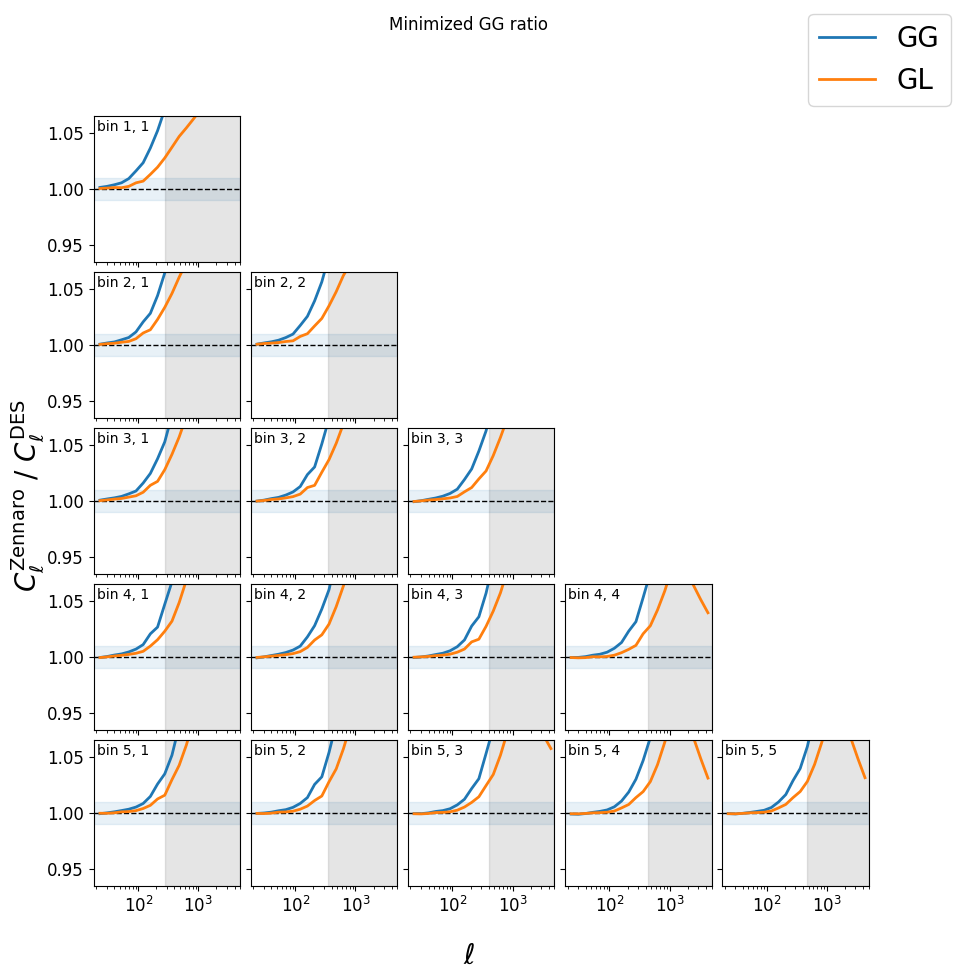

In [7]:
# plot ratio
kmax07 = [482, 616, 716, 780, 818]
kmax04 = [273, 352, 409, 445, 467]
ell_cuts = [kmax04]
fig, ax = plt.subplots(nbin, nbin, figsize=(10, 10), sharey='row', sharex=True)
fig.subplots_adjust(wspace=0.07, hspace=0.07)
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ax[i][j].axhline(y=1.0, color='k', linestyle='--', linewidth=1, label='_nolegend_')   

            ax[i,j].plot(ell_g, R_gg[:,i,j], linewidth=2)
            ax[i,j].plot(ell_g, R_gl[:,i,j], linewidth=2)

            ax[i,j].set_xscale('log')
            ax[i,j].text(.2, .9, f'bin {i+1}, {j+1}', fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)  
            ax[i,j].tick_params(axis='both', which='major', labelsize=12)        
            ax[i,j].set_xlim(18, 5000)
            ax[i,j].set_ylim(0.935, 1.065)
            ax[i,j].axhspan(0.99, 1.01, color='C0', alpha=0.1, label='_nolegend_')
            for cuts in ell_cuts:
                ax[i,j].axvspan(5000, cuts[j], color='k', alpha=0.1, label='_nolegend_') #GG cuts
        else:
            ax[i,j].axis('off')
fig.legend(['GG', 'GL'], fontsize=20)
fig.text(0.06, 0.5, r'$C_\ell^{\rm Zennaro}$ / $C_\ell^{\rm DES}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20) 
fig.suptitle('Minimized GG ratio') 
plt.show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## Ratio for fixed bias and different $logM_C$

In [8]:
# Reset to fiducials
params['b2L_1'] = 0.1127485
params['b2L_2'] = 0.0036835
params['b2L_3'] = -0.1261985
params['b2L_4'] = -0.285537
params['b2L_5'] = -0.406101
params['bs2L_1'] = 0.1127485
params['bs2L_2'] = 0.0036835
params['bs2L_3'] = -0.1261985
params['bs2L_4'] = -0.285537
params['bs2L_5'] = -0.406101
params['blaplL_1'] = -0.100126
params['blaplL_2'] = -0.1563475
params['blaplL_3'] = -0.115281
params['blaplL_4'] = 0.1059295
params['blaplL_5'] = 0.361450

n_values = 5
logMc_arr = np.linspace(9., 15., n_values)
cl_gl_sqr = np.zeros((n_values, len(ell_x), nbin, nbin))
cl_gl_des = np.zeros((n_values, len(ell_x), nbin, nbin))
for i in range(n_values):
    params['log10Mc_bc'] = logMc_arr[i]
    _, _, _, cl_gl_sqr[i] = MGL.get_c_ells(params, model_sqr)
    _, _, _, cl_gl_des[i] = MGL.get_c_ells(params, model_des)

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...


/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

...

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2561233/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.5.2. This might lead to

L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator

### Galaxy-matter power spectra (example with logMc = 13.8)

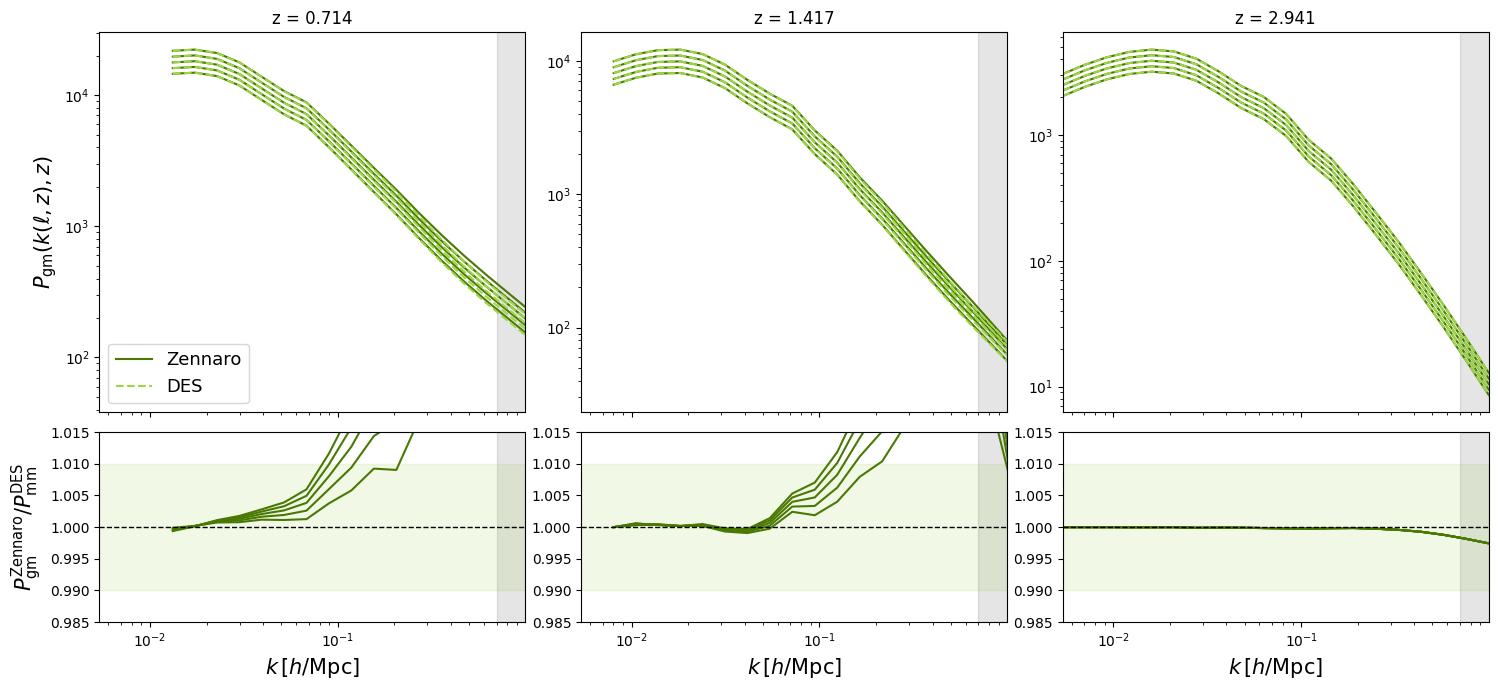

In [9]:
z_indices = [60, 120, 250] 

fig, ax = plt.subplots(2, 3, figsize=(15, 7), facecolor='w', gridspec_kw={'height_ratios':[2,1] }, sharex=True)
for i in range(len(z_indices)):
    k = k_arr[:,z_indices[i]]
    for b in range(nbin):
        ax[0][i].loglog(k, pgm_sqr[:,z_indices[i],b], color="#4A7903", linestyle='-')
        ax[0][i].loglog(k, pgm_des[:,z_indices[i],b], color="#9CD743", linestyle='--')
    ax[0][i].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    ax[0][i].set_title(f'z = {zz_integr[z_indices[i]]:.3f}')                                    
    #
    for b in range(nbin):
        ax[1][i].plot(k, pgm_sqr[:,z_indices[i],b]/pgm_des[:,z_indices[i],b], color='#4A7903')
    ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
    ax[1][i].set_xlabel(r'$k\, [h/\rm Mpc]$', fontsize=15)
    ax[1][i].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    ax[1][i].axhspan(0.99, 1.01, color='#7AC011', alpha=0.1, label='_nolegend_')
    ax[1][i].set_xlim(k[0], k[-1])
    ax[1][i].set_ylim(0.985, 1.015)
legend = ['Zennaro', 'DES']
ax[0][0].legend(legend, fontsize=13)
ax[0][0].set_ylabel(r"$P_{\rm gm}(k(\ell, z), z)$", fontsize=15)
ax[1][0].set_ylabel(r"$P^{\rm Zennaro}_{\rm gm}/P_{\rm mm}^{\rm DES}$", fontsize=15)
plt.tight_layout()

### Angular power spectra

Text(0.5, 0.04, '$\\ell$')

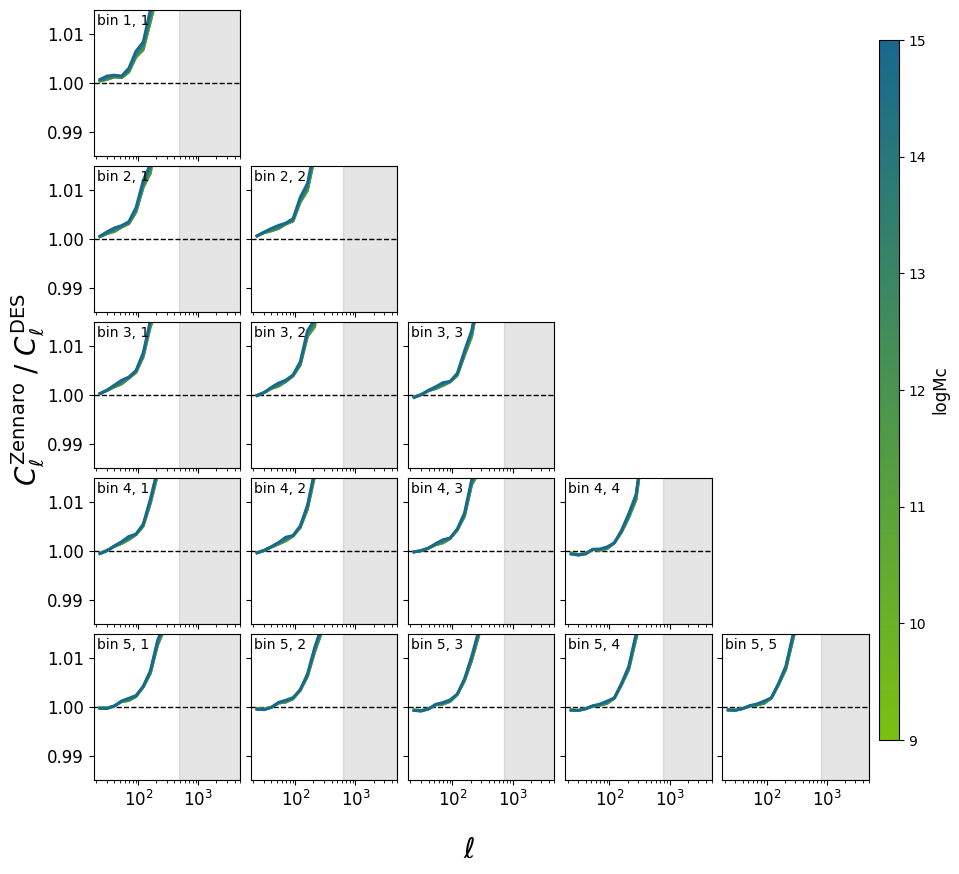

In [10]:
ell_cuts = [kmax07]
ell_list = [ell_l, ell_g, ell_x]
fig, ax = plt.subplots(nbin, nbin, figsize=(10, 10), sharey='row', sharex=True)
cmap = LinearSegmentedColormap.from_list("", ["#7AC011","#18698F"])
# normalize parameter values for the colormap
norm = Normalize(vmin=min(logMc_arr), vmax=max(logMc_arr))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 

fig.subplots_adjust(wspace=0.07, hspace=0.07)
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ax[i][j].axhline(y=1.0, color='k', linestyle='--', linewidth=1, label='_nolegend_')   
            for c in range(n_values):
                color = cmap(norm(logMc_arr[c]))
                ax[i,j].plot(ell_x, cl_gl_sqr[c][:,i,j]/cl_gl_des[c][:,i,j], color=color, linewidth=2)
            ax[i,j].set_xscale('log')
            ax[i,j].text(.2, .9, f'bin {i+1}, {j+1}', fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)  
            ax[i,j].tick_params(axis='both', which='major', labelsize=12)        
            ax[i,j].set_xlim(18, 5000)
            ax[i,j].set_ylim(0.985, 1.015)
            for cuts in ell_cuts:
                ax[i,j].axvspan(5000, cuts[j], color='k', alpha=0.1, label='_nolegend_') #GG cuts
        else:
            ax[i,j].axis('off')
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('logMc', fontsize=12)
fig.text(0.06, 0.5, r'$C_\ell^{\rm Zennaro}$ / $C_\ell^{\rm DES}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)  
# plt.tight_layout()